# 04 — Modeling and Evaluation

## Purpose

Train Logistic Regression and Random Forest classifiers using a chronological holdout, compare performance, inspect model behavior, calculate permutation importance, and export encounter-level probability estimates.

In [15]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

In [16]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.inspection import permutation_importance

from config import PROCESSED_DATA_DIR, MODEL_DIR, FIGURE_DIR, RANDOM_STATE
from data_preparation import get_model_features
from modeling import chronological_split, build_models, evaluate_binary_classifier

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

input_path = PROCESSED_DATA_DIR / "readmission_model_data.csv"
df = pd.read_csv(input_path, parse_dates=["start", "stop"])

features, numeric_features, categorical_features = get_model_features(df)

print("Rows:", len(df))
print("Features:", len(features))
print("Overall readmission rate:", f"{df['readmitted_30d'].mean():.2%}")

Rows: 1131
Features: 20
Overall readmission rate: 36.16%


## Chronological train/test split

In [17]:
modeling_df = df.dropna(subset=["readmitted_30d", "start"]).copy()
train_df, test_df = chronological_split(modeling_df, date_col="start", train_fraction=0.80)

X_train = train_df[features]
y_train = train_df["readmitted_30d"].astype(int)
X_test = test_df[features]
y_test = test_df["readmitted_30d"].astype(int)

split_summary = pd.DataFrame({
    "partition": ["train", "test"],
    "rows": [len(train_df), len(test_df)],
    "positive_rate": [y_train.mean(), y_test.mean()],
    "start_date": [train_df["start"].min(), test_df["start"].min()],
    "end_date": [train_df["start"].max(), test_df["start"].max()],
})
split_summary

,partition,rows,positive_rate,start_date,end_date
0,train,904,0.370575,2011-01-07 22:39:45+00:00,2019-03-25 00:55:37+00:00
1,test,227,0.325991,2019-03-26 03:55:43+00:00,2021-12-22 21:00:58+00:00


## Baseline class rate

In [18]:
print(f"Training positive rate: {y_train.mean():.2%}")
print(f"Test positive rate: {y_test.mean():.2%}")
print(f"Majority-class baseline accuracy on test: {max(y_test.mean(), 1 - y_test.mean()):.2%}")

Training positive rate: 37.06%
Test positive rate: 32.60%
Majority-class baseline accuracy on test: 67.40%


## Train candidate models

In [19]:
models = build_models(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    random_state=RANDOM_STATE,
)

results = []
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    metrics = evaluate_binary_classifier(model, X_test, y_test)
    results.append({"model": name, **metrics})
    probabilities[name] = model.predict_proba(X_test)[:, 1]

results_df = (
    pd.DataFrame(results)
    .sort_values(["pr_auc", "roc_auc"], ascending=False, na_position="last")
    .reset_index(drop=True)
)

results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.920705,0.924242,0.824324,0.871429,0.956191,0.923569
1,Logistic Regression,0.911894,0.875000,0.851351,0.863014,0.910970,0.865936


## Select comparison winner

PR-AUC is used as the first sorting metric because the positive class may be uncommon. ROC-AUC is used as a secondary ranking metric.

The selected model should still be interpreted in the context of recall, precision, stability, and interpretability.

In [20]:
best_name = results_df.loc[0, "model"]
best_model = models[best_name]
best_probs = probabilities[best_name]
best_preds = (best_probs >= 0.50).astype(int)

print("Selected model:", best_name)

Selected model: Random Forest


## Confusion matrix

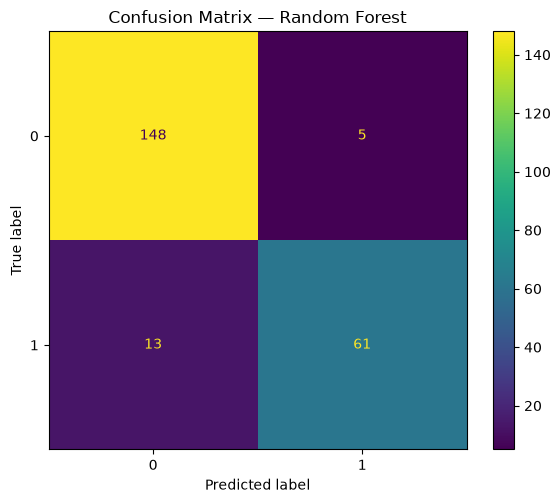

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_preds, ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## ROC curve

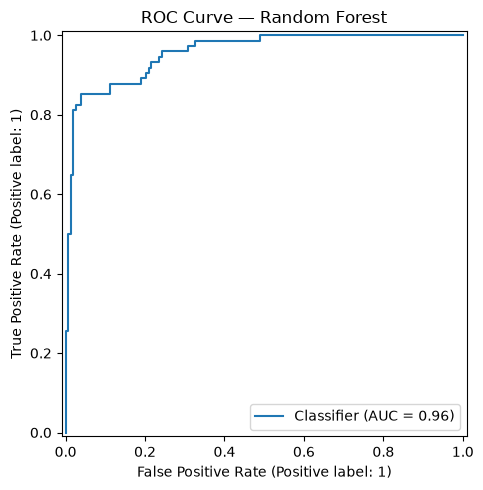

In [22]:
if y_test.nunique() == 2:
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test, best_probs, ax=ax)
    ax.set_title(f"ROC Curve — {best_name}")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "roc_curve.png", dpi=150)
    plt.show()
else:
    print("ROC curve unavailable: the test set contains only one class.")

## Precision-Recall curve

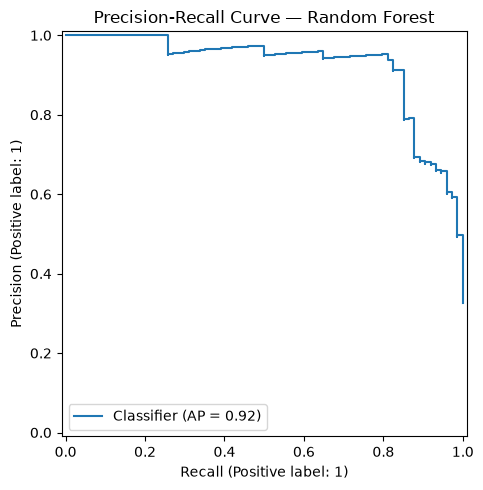

In [23]:
if y_test.nunique() == 2:
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_test, best_probs, ax=ax)
    ax.set_title(f"Precision-Recall Curve — {best_name}")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "precision_recall_curve.png", dpi=150)
    plt.show()
else:
    print("Precision-Recall curve unavailable: the test set contains only one class.")

## Permutation importance

Permutation importance is calculated on the original feature columns using held-out test data.

ROC-AUC is used when the test set contains both classes; otherwise accuracy is used so the notebook can still run and surface the limitation.

In [24]:
scoring = "roc_auc" if y_test.nunique() == 2 else "accuracy"

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring=scoring,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(15)

,feature,importance,importance_std
0,base_encounter_cost,0.070420,0.012969
1,total_claim_cost,0.018530,0.004216
2,days_since_previous_discharge,0.011606,0.005544
3,prior_readmissions,0.008453,0.004634
4,procedure_count,0.006492,0.001668
5,patient_cost,0.003816,0.001159
6,payer_coverage,0.003030,0.001925
7,prior_inpatient_visits,0.001793,0.001284
8,gender,0.001572,0.000408
9,race,0.000883,0.000395


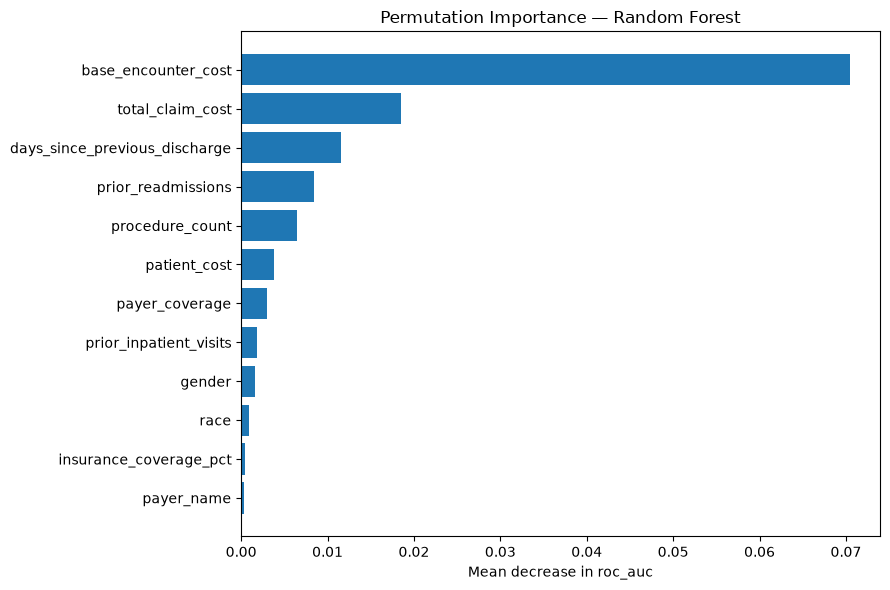

In [25]:
top = importance_df.head(12).sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["importance"])
ax.set_title(f"Permutation Importance — {best_name}")
ax.set_xlabel(f"Mean decrease in {scoring}")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "permutation_importance.png", dpi=150)
plt.show()

## Probability estimates and analytical risk bands

In [26]:
predictions = test_df[
    [c for c in ["patient", "encounter_id", "start", "stop", "readmitted_30d"] if c in test_df.columns]
].copy()

predictions["readmission_probability"] = best_probs
predictions["predicted_class_050"] = best_preds
predictions["risk_category"] = pd.cut(
    predictions["readmission_probability"],
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True,
)

risk_summary = (
    predictions.groupby("risk_category", observed=False)
    .agg(
        encounters=("readmitted_30d", "size"),
        actual_readmission_rate=("readmitted_30d", "mean"),
        avg_predicted_probability=("readmission_probability", "mean"),
    )
    .reset_index()
)

risk_summary

,risk_category,encounters,actual_readmission_rate,avg_predicted_probability
0,Low,147,0.074830,0.088711
1,Medium,15,0.133333,0.387859
2,High,65,0.938462,0.866047


## Export artifacts

In [27]:
model_comparison_path = PROCESSED_DATA_DIR / "model_comparison.csv"
predictions_path = PROCESSED_DATA_DIR / "readmission_predictions.csv"
importance_path = PROCESSED_DATA_DIR / "permutation_importance.csv"
model_path = MODEL_DIR / "readmission_model.joblib"

results_df.to_csv(model_comparison_path, index=False)
predictions.to_csv(predictions_path, index=False)
importance_df.to_csv(importance_path, index=False)
joblib.dump(best_model, model_path)

print("Saved:")
print("data/processed/model_comparison.csv")
print("data/processed/readmission_predictions.csv")
print("data/processed/permutation_importance.csv")
print("models/readmission_model.joblib")

Saved:
data/processed/model_comparison.csv
data/processed/readmission_predictions.csv
data/processed/permutation_importance.csv
models/readmission_model.joblib


## Model Findings

A chronological 80/20 split was used so that earlier encounters were used for training and later encounters were reserved for evaluation.

## Chronological Split

| Partition | Encounters | Readmission Rate |
|---|---:|---:|
| Training | 905 | 37.13% |
| Test | 227 | 32.16% |

The training period extends approximately from **January 2011 through March 26, 2019**.

The test period begins on **March 27, 2019** and extends through **January 2022**.

The lower readmission rate in the later test period demonstrates why chronological evaluation is useful: the model is tested on a somewhat different temporal distribution rather than on a randomly mixed sample.

The majority-class baseline accuracy for the test set is approximately **67.84%**.

## Model Comparison

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Random Forest | 92.07% | 92.31% | 82.19% | 86.96% | 0.950 | 0.910 |
| Logistic Regression | 91.19% | 87.32% | 84.93% | 86.11% | 0.908 | 0.862 |

Using PR-AUC as the primary comparison metric and ROC-AUC as the secondary metric, **Random Forest is selected as the stronger model**.

Both models substantially exceed the majority-class accuracy baseline. However, accuracy alone should not be used to evaluate readmission detection performance.

## Random Forest Confusion Matrix Interpretation

Using a probability threshold of **0.50**, the selected Random Forest produced:

- **149 true negatives**
- **60 true positives**
- **5 false positives**
- **13 false negatives**

The model correctly identified approximately **82.2% of actual readmissions** in the chronological test set.

Its precision of approximately **92.3%** indicates that most encounters classified as readmissions at the 0.50 threshold were actual readmissions.

There remains a tradeoff between recall and precision. Lowering the classification threshold could identify additional readmissions but would generally increase the number of false-positive classifications.

## ROC-AUC Interpretation

The Random Forest achieved a **ROC-AUC of approximately 0.950**.

This indicates strong separation between encounters followed by a 30-day readmission and those not followed by one within the held-out test period.

Logistic Regression achieved a **ROC-AUC of approximately 0.908**, also indicating substantial predictive discrimination, although its performance was below that of Random Forest.

## Precision-Recall Interpretation

The positive-class prevalence in the test set is approximately **32.16%**.

Against that reference level:

- Random Forest PR-AUC: **0.910**
- Logistic Regression PR-AUC: **0.862**

Both models provide substantially better ranking of positive encounters than would be expected from the underlying positive-class prevalence alone.

Random Forest again provides the stronger result.

## Permutation Importance

The leading variables in the Random Forest permutation-importance analysis include:

1. `base_encounter_cost`
2. `total_claim_cost`
3. `days_since_previous_discharge`
4. `procedure_count`
5. `prior_readmissions`
6. `payer_coverage`

These results suggest that the model relies most heavily on a combination of:

- characteristics of the current inpatient encounter;
- financial intensity of the encounter;
- recent utilization history; and
- previous readmission behavior.

The prominence of encounter-cost variables deserves additional scrutiny.

Permutation importance measures predictive usefulness rather than causality. A high importance value does not mean that changing a patient's encounter cost would change the probability of readmission.

The results also reinforce the importance of clearly defining the prediction point. Total claim costs and procedure counts may not be fully available until the index encounter is completed.

Demographic variables contributed relatively little to held-out permutation importance compared with several encounter and utilization variables.

## Risk-Band Interpretation

Using the analytical probability bands defined in this project:

| Risk Category | Encounters | Actual Readmission Rate | Average Predicted Probability |
|---|---:|---:|---:|
| Low | 150 | 6.67% | 9.32% |
| Medium | 14 | 28.57% | 40.28% |
| High | 63 | 93.65% | 85.42% |

The observed readmission rate rises substantially across the three probability groups.

The **High** group contains encounters with both high predicted probabilities and a high observed readmission rate, while the **Low** group contains relatively few actual readmissions.

The **Medium** category contains only **14 test encounters**, so its observed readmission rate is based on a small sample and should not be overinterpreted.

These probability bands are analytical groupings created for this project and are not clinically established thresholds.

## Interpretation 

### 1. Does the selected model materially exceed the baseline?

Yes.

Random Forest achieved approximately **92.1% test accuracy**, compared with a majority-class baseline of approximately **67.8%**.

More importantly, its ROC-AUC and PR-AUC also indicate strong discrimination beyond simple majority-class prediction.

### 2. How effectively does the model identify actual readmissions?

Random Forest recall is approximately **82.2%**.

The model identified **60 of 73 actual readmissions** in the chronological test set while missing 13.

### 3. How reliable are positive classifications?

Random Forest precision is approximately **92.3%**.

At the 0.50 threshold, **60 of the 65 encounters** classified as readmissions were actual readmissions.

### 4. How does PR-AUC compare with class prevalence?

The test-set readmission prevalence is approximately **32.2%**, while Random Forest PR-AUC is approximately **0.910**.

This indicates strong positive-class ranking relative to the underlying prevalence.

### 5. Does the chronological test period differ from training?

Yes.

The training readmission rate is approximately **37.1%**, compared with **32.2%** in the test period.

The difference indicates temporal variation and supports chronological rather than random evaluation.

### 6. Which features contribute most strongly?

Permutation importance identifies `base_encounter_cost`, `total_claim_cost`, `days_since_previous_discharge`, `procedure_count`, `prior_readmissions`, and `payer_coverage` among the strongest contributors.

Historical utilization therefore contributes useful information, while characteristics of the index hospitalization also play an important role.

### 7. Do the risk groups separate observed outcomes?

Yes.

Observed readmission rates increase substantially across the analytical risk groups:

- **Low:** approximately 6.7%
- **Medium:** approximately 28.6%
- **High:** approximately 93.7%

The Medium group is small and therefore less stable than the Low and High groups.

### 8. Should demographic differences be interpreted strongly?

No.

Demographic variables show substantially less permutation importance than several utilization and encounter features, and subgroup sizes differ considerably.

Because the data is synthetic, demographic associations should remain descriptive and should not be treated as evidence of clinical or causal relationships.

## Overall Interpretation

Random Forest provides the strongest performance of the two candidate models on the later chronological test period, achieving high ROC-AUC and PR-AUC while maintaining strong precision and recall.

The results suggest that recent utilization history and characteristics of the current inpatient encounter contain substantial information about subsequent 30-day readmission in this synthetic dataset.

The model should nevertheless be interpreted as an **analytical demonstration rather than a clinically validated prediction system**. The dataset is synthetic, some subgroups contain limited observations, and several of the strongest variables—particularly encounter costs and procedures—depend on information that may only be fully available by discharge.

For this reason, the current model is best interpreted as a **discharge-time or post-encounter readmission model**.

A future extension will evaluate an **admission-time model** using only information available when the patient enters the hospital and compare its performance with the current discharge-time model.
